In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import smarts_cerebellum.globals as gl

lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', 'patients_MNISymC_FaMap_CST_lme.tsv'), sep = '\t')
lme['Week'] = lme['Week'].astype(int)
lme = lme.sort_values('Week')

obs = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_FaMap', 'summary_MNISymC_CST_FaMap.tsv'), sep = '\t')
#mcp = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_FaMap', 'summary_MNISymC_MCP_FaMap.tsv'), sep = '\t')

In [3]:
lme.subj_id.unique()

array(['CU_2310', 'CU_2538', 'CU_2663', 'CU_2697', 'CU_2925', 'JHU_2282',
       'JHU_2374', 'JHU_2395', 'JHU_2531', 'JHU_2577', 'JHU_2650',
       'JHU_2684', 'JHU_2713', 'JHU_2789', 'JHU_3175', 'JHU_3176',
       'UZ_2365', 'UZ_2450', 'UZ_2565'], dtype=object)

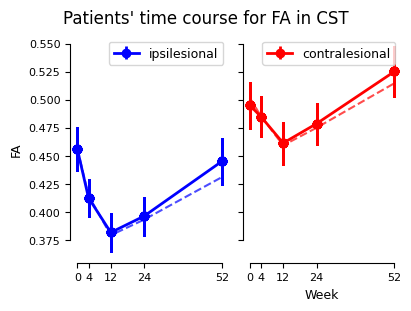

In [19]:
fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

lme_ipsi = lme[(lme.regionname == 'right_CST')].sort_values('Week')
lme_contra = lme[(lme.regionname == 'left_CST')].sort_values('Week')

obs_ipsi = obs[obs.regionname == 'CSTR'].groupby('Week')['mean'].mean().reset_index()
obs_contra = obs[obs.regionname == 'CSTL'].groupby('Week')['mean'].mean().reset_index()

axs[0].errorbar(x = lme_ipsi['Week'], y = lme_ipsi['beta'], yerr = lme_ipsi['se'], fmt = '-o', linewidth = 2, color = 'blue', label = 'ipsilesional')
axs[1].errorbar(x = lme_contra['Week'], y = lme_contra['beta'], yerr = lme_contra['se'], fmt = '-o', linewidth = 2, color = 'red', label = 'contralesional')

axs[0].plot(obs_ipsi['Week'], obs_ipsi['mean'], alpha = .7, linestyle = '--', color = 'blue')
axs[1].plot(obs_contra['Week'], obs_contra['mean'], alpha = .7, linestyle = '--', color = 'red')

for ax in axs:
    ax.legend()
    ax.set_xticks(gl.weeks)
    axs[0].set_ylabel("FA")
    axs[1].set_xlabel("Week")

plt.suptitle(f"Patients' time course for FA in CST")
sns.despine(trim = True)
plt.show()

these changes (the upward trend from W12 to W52) was also obs in the DTI Jing provided (with Mori's atlas), but to a considerably lesser degree. I think these changes are not super robust, just atlas-dependent.

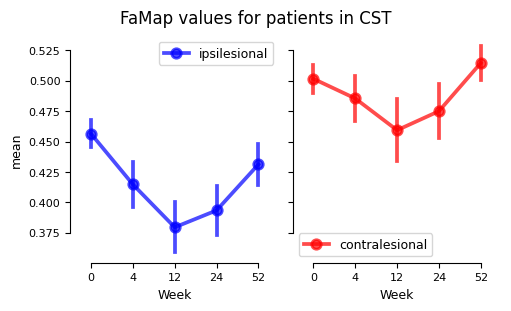

In [ ]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, sharex = True, constrained_layout = True)
sns.pointplot(x = 'Week', y = 'mean', data = cst_obs[cst_obs.group == 'ipsilesional'], alpha = .7, label = f'ipsilesional', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'Week', y = 'mean', data = cst_obs[cst_obs.group == 'contralesional'], alpha = .7, label = f'contralesional', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'FaMap values for patients in CST')
plt.legend()
sns.despine(trim = True)
plt.show()

In [10]:
from scipy import stats

print(f'---t-test between ipsilesional and contralesional CST patients--- \n')

for week in cst.Week.unique():
    t_val, p_val = stats.ttest_rel(cst[(cst.Week == week) & (cst.regionname == f'CSTR')]['mean'], cst[(cst.Week == week) & (cst.regionname == f'CSTL')]['mean'])
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')
    

---t-test between ipsilesional and contralesional CST patients--- 



NameError: name 'cst' is not defined

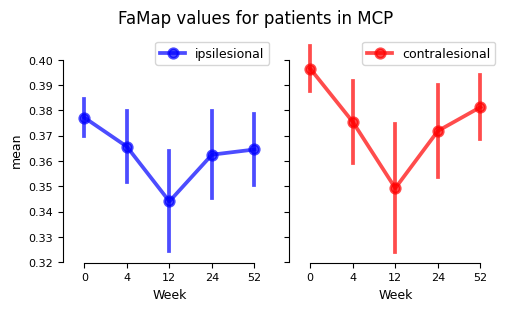

In [ ]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, sharex = True, constrained_layout = True)
sns.pointplot(x = 'Week', y = 'mean', data = mcp[mcp.group == 'ipsilesional'], alpha = .7, label = f'ipsilesional', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'Week', y = 'mean', data = mcp[mcp.group == 'contralesional'], alpha = .7, label = f'contralesional', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'FaMap values for patients in MCP')
plt.legend()
sns.despine(trim = True)
plt.show()